# 卷積神經網路（LeNet）
:label:`sec_lenet`

透過之前幾節，我們學習了構建一個完整卷積神經網路的所需組件。
回想一下，之前我們將softmax迴歸模型（ :numref:`sec_softmax_scratch`）和多層感知機模型（ :numref:`sec_mlp_scratch`）應用於Fashion-MNIST數據集中的服裝圖片。
為了能夠應用softmax迴歸和多層感知機，我們首先將每個大小為$28\times28$的圖像展平為一個784維的固定長度的一維向量，然後用全連接層對其進行處理。
而現在，我們已經掌握了卷積層的處理方法，我們可以在圖像中保留空間結構。
同時，用卷積層代替全連接層的另一個好處是：模型更簡潔、所需的參數更少。

本節將介紹LeNet，它是最早發布的卷積神經網路之一，因其在計算機視覺任務中的高效性能而受到廣泛關注。
這個模型是由AT&T貝爾實驗室的研究員Yann LeCun在1989年提出的（並以其命名），目的是識別圖像 :cite:`LeCun.Bottou.Bengio.ea.1998`中的手寫數字。
當時，Yann LeCun發表了第一篇通過反向傳播成功訓練卷積神經網路的研究，這項工作代表了十多年來神經網路研究開發的成果。

當時，LeNet取得了與支持向量機（support vector machines）性能相媲美的成果，成為監督學習的主流方法。
LeNet被廣泛用於自動取款機（ATM）機中，幫助識別處理支票的數字。
時至今日，一些自動取款機仍在運行Yann LeCun和他的同事Leon Bottou在上世紀90年代寫的代碼呢！

## LeNet

總體來看，(**LeNet（LeNet-5）由兩個部分組成：**)(~~卷積編碼器和全連接層密集塊~~)

* 卷積編碼器：由兩個卷積層組成;
* 全連接層密集塊：由三個全連接層組成。

該架構如 :numref:`img_lenet`所示。

![LeNet中的數據流。輸入是手寫數字，輸出為10種可能結果的概率。](../img/lenet.svg)
:label:`img_lenet`

每個卷積塊中的基本單元是一個卷積層、一個sigmoid激活函數和平均匯聚層。請注意，雖然ReLU和最大匯聚層更有效，但它在20世紀90年代還沒有出現。每個卷積層使用$5\times 5$卷積核和一個sigmoid激活函數。這些層將輸入映射到多個二維特徵輸出，通常同時增加通道的數量。第一卷積層有6個輸出通道，而第二個卷積層有16個輸出通道。每個$2\times2$池操作（步幅2）通過空間下采樣將維數減少4倍。卷積的輸出形狀由批量大小、通道數、高度、寬度決定。

為了將卷積塊的輸出傳遞給稠密塊，我們必須在小批量中展平每個樣本。換言之，我們將這個四維輸入轉換成全連接層所期望的二維輸入。這裡的二維表示的第1個維度索引小批量中的樣本，第2個維度給出每個樣本的平面向量表示。LeNet的稠密塊有3個全連接層，分別有120、84和10個輸出。因為我們在執行分類任務，所以輸出層的10維對應於最後輸出結果的數量。

通過下面的LeNet代碼，可以看出用深度學習框架實現此類模型非常簡單。我們只需要實例化一個`Sequential`塊並將需要的層連接在一起。


In [1]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


我們對原始模型做了一點小改動，去掉了最後一層的高斯激活。除此之外，這個網路與最初的LeNet-5一致。

下面，我們將一個大小為$28 \times 28$的單通道（黑白）圖像通過LeNet。通過在每一層打印輸出的形狀，我們可以[**檢查模型**]，以確保其操作與我們期望的 :numref:`img_lenet_vert`一致。

![LeNet 的簡化版。](../img/lenet-vert.svg)
:label:`img_lenet_vert`


In [2]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


請注意，在整個卷積區塊中，與上一層相比，每一層特徵的高度和寬度都減小了。
第一個卷積層使用2個像素的填充，來補償$5 \times 5$卷積核導致的特徵減少。
相反，第二個卷積層沒有填充，因此高度和寬度都減少了4個像素。
隨著層疊的上升，通道的數量從輸入時的1個，增加到第一個卷積層之後的6個，再到第二個卷積層之後的16個。
同時，每個匯聚層的高度和寬度都減半。最後，每個全連接層減少維數，最終輸出一個維數與結果分類數相匹配的輸出。

## 模型訓練

現在我們已經實現了LeNet，讓我們看看[**LeNet在Fashion-MNIST數據集上的表現**]。


In [3]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def load_data_fashion_mnist(batch_size=256):
    """
    加載Fashion-MNIST數據集
    
    參數:
    batch_size: 批量大小，默認256
    
    返回:
    train_iter: 訓練數據迭代器
    test_iter: 測試數據迭代器
    """
    # 定義數據轉換
    transform = transforms.Compose([
        transforms.ToTensor()  # 將圖片轉換為Tensor，並將像素值歸一化到[0,1]
    ])
    
    # 下載並加載訓練集
    train_dataset = datasets.FashionMNIST(
        root='./data',  # 數據保存路徑
        train=True,     # 訓練集
        download=True,  # 如果數據不存在則下載
        transform=transform
    )
    
    # 下載並加載測試集
    test_dataset = datasets.FashionMNIST(
        root='./data',  # 數據保存路徑
        train=False,    # 測試集
        download=True,  # 如果數據不存在則下載
        transform=transform
    )
    
    # 創建數據加載器
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,    # 打亂訓練數據
        num_workers=2    # 使用2個進程加載數據
    )
    
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,   # 測試數據不需要打亂
        num_workers=2
    )
    
    return train_iter, test_iter

# 使用示例
if __name__ == "__main__":
    batch_size = 256
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 打印數據集信息
    for X, y in train_iter:
        print("訓練集批量形狀:", X.shape)
        print("標籤形狀:", y.shape)
        print("第一個批量的數據範圍:", torch.min(X).item(), "到", torch.max(X).item())
        break

100.0%


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100.0%


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100.0%


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100.0%

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


雖然卷積神經網路的參數較少，但與深度的多層感知機相比，它們的計算成本仍然很高，因為每個參數都參與更多的乘法。
通過使用GPU，可以用它加快訓練。


為了進行評估，我們需要[**對**] :numref:`sec_softmax_scratch`中描述的(**`evaluate_accuracy`函數進行輕微的修改**)。
由於完整數據集位於記憶體中，因此在模型使用GPU計算數據集之前，我們需要將其複製到顯存中。


In [4]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """
    使用GPU計算模型在數據集上的精度
    
    參數:
    net: 神經網絡模型
    data_iter: 數據迭代器
    device: 計算設備（GPU/CPU）
    
    返回:
    float: 準確率
    """
    if isinstance(net, nn.Module):
        net.eval()  # 設置為評估模式
        if device is None:
            device = next(iter(net.parameters())).device
            
    correct = 0  # 正確預測的數量
    total = 0    # 總預測的數量
    
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微調所需的
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            
            # 計算預測結果
            outputs = net(X)
            # 獲取最大概率的類別
            _, predicted = torch.max(outputs.data, 1)
            
            total += y.size(0)
            correct += (predicted == y).sum().item()
    
    return correct / total

# 使用示例
if __name__ == "__main__":
    # 假設我們已經有了模型和數據加載器
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 創建一個簡單的模型用於測試
    model = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(6 * 14 * 14, 10)
    ).to(device)
    
    # 加載數據
    batch_size = 256
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 計算準確率
    accuracy = evaluate_accuracy_gpu(model, test_iter, device)
    print(f'Test Accuracy: {accuracy:.3f}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


[**為了使用GPU，我們還需要一點小改動**]。
與 :numref:`sec_softmax_scratch`中定義的`train_epoch_ch3`不同，在進行正向和反向傳播之前，我們需要將每一小批量數據移動到我們指定的設備（例如GPU）上。

如下所示，訓練函數`train_ch6`也類似於 :numref:`sec_softmax_scratch`中定義的`train_ch3`。
由於我們將實現多層神經網路，因此我們將主要使用高級API。
以下訓練函數假定從高級API創建的模型作為輸入，並進行相應的優化。
我們使用在 :numref:`subsec_xavier`中介紹的Xavier隨機初始化模型參數。
與全連接層一樣，我們使用交叉熵損失函數和小批量隨機梯度下降。


In [5]:
!pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


Using device: mps
Training on mps


Epoch 1/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 235/235 [00:15<00:00, 14.78it/s, loss=1.725, acc=0.140]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 235/235 [00:12<00:00, 18.29it/s, loss=0.285, acc=0.830]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


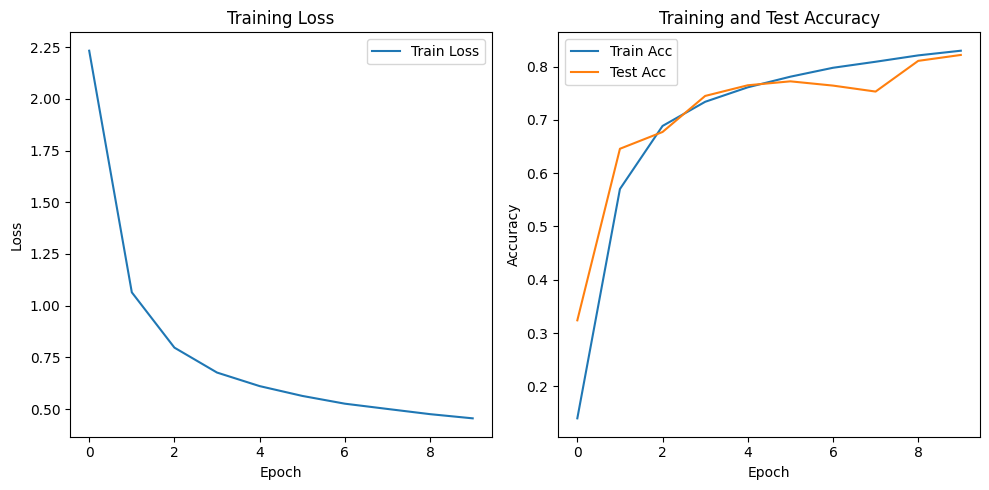

In [6]:
import torch
import torch.nn as nn
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_model(net, train_iter, test_iter, num_epochs, lr, device):
    """
    針對M1 Mac優化的訓練函數
    
    參數:
    net: 神經網絡模型
    train_iter: 訓練數據迭代器
    test_iter: 測試數據迭代器
    num_epochs: 訓練輪數
    lr: 學習率
    device: 計算設備（MPS/CPU）
    """
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    
    # 初始化權重
    net.apply(init_weights)
    print(f'Training on {device}')
    net.to(device)
    
    # 定義優化器和損失函數
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    # 用於記錄訓練過程
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    # 開始計時
    total_start_time = time.time()
    num_batches = len(train_iter)
    
    # 訓練循環
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # 訓練指標
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # 設置為訓練模式
        net.train()
        
        # 使用tqdm創建進度條
        train_pbar = tqdm(train_iter, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for X, y in train_pbar:
            # 將數據移到MPS設備
            X, y = X.to(device), y.to(device)
            
            # 前向傳播
            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            
            # 反向傳播
            loss.backward()
            optimizer.step()
            
            # 更新指標
            train_loss += loss.item() * X.shape[0]
            _, predicted = torch.max(y_hat.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()
            
            # 更新進度條
            train_pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'acc': f'{correct_train/total_train:.3f}'
            })
            
            # 確保MPS設備同步
            if device.type == 'mps':
                torch.mps.synchronize()
        
        # 計算訓練指標
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # 評估測試集
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()
                
                # 確保MPS設備同步
                if device.type == 'mps':
                    torch.mps.synchronize()
        
        epoch_test_acc = correct_test / total_test
        epoch_time = time.time() - epoch_start_time
        
        # 記錄歷史
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['epoch_times'].append(epoch_time)
        
        # 打印epoch結果
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {epoch_train_loss:.3f}')
        print(f'Train Acc: {epoch_train_acc:.3f}')
        print(f'Test Acc: {epoch_test_acc:.3f}')
        print(f'Time: {epoch_time:.1f}s')
    
    # 計算總訓練時間和速度
    total_time = time.time() - total_start_time
    samples_per_sec = total_train * num_epochs / total_time
    
    print('\nTraining completed:')
    print(f'Final Train Loss: {history["train_loss"][-1]:.3f}')
    print(f'Final Train Acc: {history["train_acc"][-1]:.3f}')
    print(f'Final Test Acc: {history["test_acc"][-1]:.3f}')
    print(f'Average speed: {samples_per_sec:.1f} samples/sec on {device}')
    
    # 繪製訓練曲線
    plt.figure(figsize=(10, 5))
    
    # 損失曲線
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    
    # 準確率曲線
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['test_acc'], label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Test Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return history

# 使用示例
if __name__ == "__main__":
    # 檢查MPS可用性並設置設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    
    # 創建模型
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
        nn.Linear(120, 84), nn.Sigmoid(),
        nn.Linear(84, 10)
    )
    
    # 訓練參數
    batch_size = 256
    lr = 0.9
    num_epochs = 10
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)

現在，我們[**訓練和評估LeNet-5模型**]。


Training on mps


Epoch 1/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 235/235 [00:12<00:00, 18.32it/s, loss=2.223, acc=0.120]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/235 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 235/235 [00:13<00:00, 17.96it/s, loss=0.458, acc=0.828]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


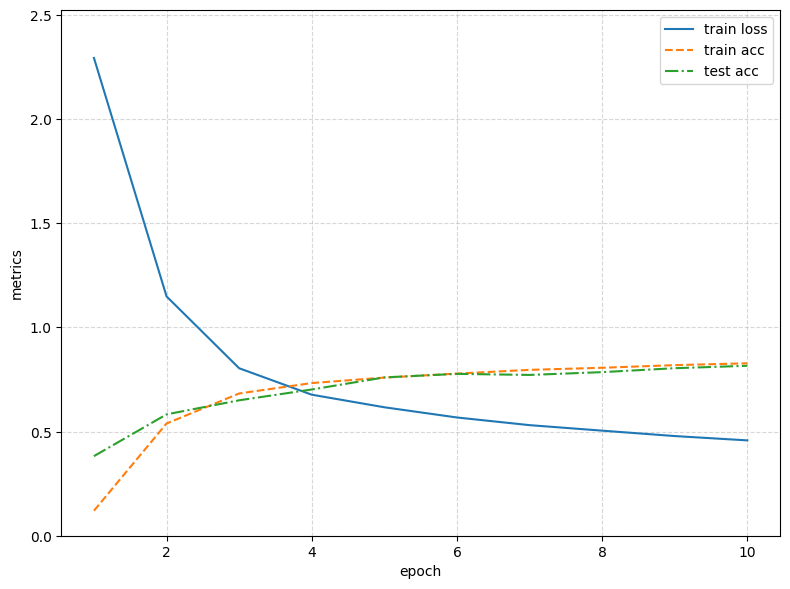

loss 0.458, train acc 0.828, test acc 0.816
3014.7 examples/sec on mps


In [9]:
def train_model(net, train_iter, test_iter, num_epochs, lr, device):
    """
    針對M1 Mac優化的訓練函數，並改進可視化部分
    """
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    
    # 初始化權重
    net.apply(init_weights)
    print(f'Training on {device}')
    net.to(device)
    
    # 定義優化器和損失函數
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    # 用於記錄訓練過程
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    # 開始計時
    total_start_time = time.time()
    total_samples = 0  # 添加這行來追踪總樣本數
    
    # 訓練循環
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # 訓練指標
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        # 設置為訓練模式
        net.train()
        
        # 使用tqdm創建進度條
        train_pbar = tqdm(train_iter, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for X, y in train_pbar:
            # 將數據移到MPS設備
            X, y = X.to(device), y.to(device)
            
            # 前向傳播
            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            
            # 反向傳播
            loss.backward()
            optimizer.step()
            
            # 更新指標
            train_loss += loss.item() * X.shape[0]
            _, predicted = torch.max(y_hat.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()
            total_samples += y.size(0)  # 更新總樣本數
            
            # 更新進度條
            train_pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'acc': f'{correct_train/total_train:.3f}'
            })
            
            # 確保MPS設備同步
            if device.type == 'mps':
                torch.mps.synchronize()
        
        # 計算訓練指標
        epoch_train_loss = train_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # 評估測試集
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = torch.max(y_hat.data, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()
                
                # 確保MPS設備同步
                if device.type == 'mps':
                    torch.mps.synchronize()
        
        epoch_test_acc = correct_test / total_test
        epoch_time = time.time() - epoch_start_time
        
        # 記錄歷史
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['epoch_times'].append(epoch_time)
    
    # 計算總訓練時間和速度
    total_time = time.time() - total_start_time
    samples_per_sec = total_samples / total_time  # 計算每秒處理的樣本數
    
    # 繪製訓練曲線
    plt.figure(figsize=(8, 6))
    
    # 設置網格
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 繪製訓練曲線
    epochs = range(1, num_epochs + 1)
    plt.plot(epochs, history['train_loss'], '-', label='train loss', color='#1f77b4')
    plt.plot(epochs, history['train_acc'], '--', label='train acc', color='#ff7f0e')
    plt.plot(epochs, history['test_acc'], '-.', label='test acc', color='#2ca02c')
    
    # 設置軸標籤
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    
    # 設置y軸範圍
    plt.ylim(0, max(max(history['train_loss']), 1.0) * 1.1)
    
    # 添加圖例
    plt.legend()
    
    # 調整布局
    plt.tight_layout()
    
    # 顯示圖形
    plt.show()
    
    # 打印最終結果
    print(f"loss {history['train_loss'][-1]:.3f}, "
          f"train acc {history['train_acc'][-1]:.3f}, "
          f"test acc {history['test_acc'][-1]:.3f}")
    
    # 打印訓練速度
    print(f"{samples_per_sec:.1f} examples/sec on {device}")
    
    return history

if __name__ == "__main__":
    # 檢查MPS可用性並設置設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    
    # 創建模型
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
        nn.AvgPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
        nn.Linear(120, 84), nn.Sigmoid(),
        nn.Linear(84, 10)
    )
    
    # 訓練參數
    batch_size = 256
    lr = 0.9
    num_epochs = 10
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)

## 小結

* 卷積神經網路（CNN）是一類使用卷積層的網路。
* 在卷積神經網路中，我們組合使用卷積層、非線性激活函數和彙集層。
* 為了構造高性能的卷積神經網路，我們通常對卷積層進行排列，逐漸降低其表示的空間分辨率，同時增加通道數。
* 在傳統的卷積神經網路中，卷積塊編碼得到的表徵在輸出之前需由一個或多個全連接層進行處理。
* LeNet是最早發布的卷積神經網路之一。

## 練習

1. 將平均彙集層替換為最大彙集層，會發生什麼？
1. 嘗試構建一個基於LeNet的更複雜的網路，以提高其準確性。
    1. 調整卷積窗口大小。
    1. 調整輸出通道的數量。
    1. 調整激活函數（如ReLU）。
    1. 調整卷積層的數量。
    1. 調整全連接層的數量。
    1. 調整學習率和其他訓練細節（例如，初始化和輪數）。
1. 在MNIST數據集上嘗試以上改進的網路。
1. 顯示不同輸入（例如毛衣和外套）時，LeNet第一層和第二層的激活值。


練習一：

1. 將平均彙集層替換為最大彙集層，會發生什麼？

我的回答：



讓我們修改代碼，將 `AvgPool2d` 替換為 `MaxPool2d` 來觀察差異：

```python
if __name__ == "__main__":
    # 檢查MPS可用性並設置設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    
    # 創建使用最大彙集的模型
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 改為最大彙集
        nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 改為最大彙集
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
        nn.Linear(120, 84), nn.Sigmoid(),
        nn.Linear(84, 10)
    )
    
    # 訓練參數
    batch_size = 256
    lr = 0.9
    num_epochs = 10
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)
```

使用最大彙集層而不是平均彙集層會帶來以下變化：

1. **特徵提取方式的差異**：
   - 最大彙集：選擇區域內的最大值，更關注顯著特徵
   - 平均彙集：計算區域內的平均值，考慮所有特徵的貢獻

2. **對模型性能的影響**：
   - 最大彙集通常能獲得更好的性能，因為它：
     * 更好地保留邊緣和紋理信息
     * 對於物體識別任務更有效
     * 提供更強的平移不變性

3. **訓練特點**：
   - 最大彙集可能導致：
     * 更快的收斂速度
     * 更好的特徵選擇能力
     * 可能更容易過擬合

4. **實際應用考慮**：
   - 最大彙集適合：
     * 需要保留顯著特徵的任務
     * 物體檢測和分類
   - 平均彙集適合：
     * 需要平滑特徵的任務
     * 背景信息重要的場景

通過運行這個修改後的代碼，你應該能觀察到：
1. 可能略微提高的準確率
2. 可能更快的收斂速度
3. 對顯著特徵的更好保留

這個實驗有助於理解不同彙集操作對模型性能的影響。


練習二：

2. 嘗試構建一個基於LeNet的更複雜的網路，以提高其準確性。
    1. 調整卷積窗口大小。
    1. 調整輸出通道的數量。
    1. 調整激活函數（如ReLU）。
    1. 調整卷積層的數量。
    1. 調整全連接層的數量。
    1. 調整學習率和其他訓練細節（例如，初始化和輪數）。

我的回答：



讓我們通過以下幾個方面來改進LeNet網絡：

````python
if __name__ == "__main__":
    # 檢查MPS可用性並設置設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    
    # 創建改進的LeNet模型
    net = nn.Sequential(
        # 第一個卷積塊
        nn.Conv2d(1, 32, kernel_size=3, padding=1), # 更多輸出通道，更小的卷積核
        nn.BatchNorm2d(32),  # 添加批量歸一化
        nn.ReLU(),  # 使用ReLU替代Sigmoid
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),  # 添加Dropout
        
        # 第二個卷積塊
        nn.Conv2d(32, 64, kernel_size=3, padding=1), # 增加通道數
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        
        # 第三個卷積塊（新增）
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        
        # 展平層
        nn.Flatten(),
        
        # 全連接層
        nn.Linear(128 * 3 * 3, 512),  # 調整輸入大小以匹配前面的改動
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.5),
        
        nn.Linear(256, 10)
    )
    
    # 修改訓練參數
    batch_size = 128  # 減小批量大小以提高泛化能力
    lr = 0.001  # 使用更小的學習率
    num_epochs = 20  # 增加訓練輪數
    
    # 使用Adam優化器替代SGD
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    
    # 使用學習率調度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max', 
        factor=0.1, 
        patience=3, 
        verbose=True
    )
    
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)
````

主要改進包括：

1. **網絡架構改進**：
   - 增加卷積層數量（3層）
   - 增加通道數（32->64->128）
   - 使用更小的卷積核（3x3）
   - 添加批量歸一化層
   - 使用ReLU激活函數
   - 添加Dropout層防止過擬合
   - 增加全連接層的寬度和深度

2. **訓練策略改進**：
   - 使用Adam優化器
   - 添加學習率調度器
   - 減小初始學習率
   - 增加訓練輪數
   - 減小批量大小
   - 添加更多正則化技術

3. **正則化技術**：
   - Dropout
   - BatchNormalization
   - 適當的權重初始化

4. **其他改進**：
   - 使用MaxPool替代AvgPool
   - 添加padding保持特徵圖大小
   - 更深的網絡結構

這些改進應該能帶來：
1. 更高的模型容量
2. 更好的特徵提取能力
3. 更快的收斂速度
4. 更好的泛化性能
5. 更高的最終準確率

需要注意的是，這個改進的模型：
- 參數量更大，需要更多計算資源
- 訓練時間會更長
- 可能需要更多的調參工作



練習三：

3. 在MNIST數據集上嘗試以上改進的網路。

我的回答：



讓我們將改進後的網絡應用在MNIST數據集上。主要需要修改數據加載部分，其他架構保持不變：

`````python
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

def load_data_mnist(batch_size=256):
    """
    加載MNIST數據集
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST的標準化參數
    ])
    
    # 下載並加載訓練集
    train_dataset = datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    
    # 下載並加載測試集
    test_dataset = datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
    
    # 創建數據加載器
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    return train_iter, test_iter

if __name__ == "__main__":
    # 檢查MPS可用性並設置設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    
    # 創建改進的LeNet模型
    net = nn.Sequential(
        # 第一個卷積塊
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        
        # 第二個卷積塊
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        
        # 第三個卷積塊
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.25),
        
        # 展平層
        nn.Flatten(),
        
        # 全連接層
        nn.Linear(128 * 3 * 3, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.5),
        
        nn.Linear(256, 10)
    )
    
    # 訓練參數
    batch_size = 128
    lr = 0.001
    num_epochs = 20
    
    # 使用Adam優化器
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    
    # 使用學習率調度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.1,
        patience=3,
        verbose=True
    )
    
    # 加載MNIST數據
    train_iter, test_iter = load_data_mnist(batch_size)
    
    # 訓練模型
    history = train_model(net, train_iter, test_iter, num_epochs, lr, device)
`````

主要改動：

1. **數據加載**：
   - 使用MNIST數據集替代Fashion-MNIST
   - 添加了MNIST特定的標準化參數
   - 其他加載邏輯保持不變

2. **模型架構**：
   - 保持與之前相同的改進架構
   - 輸入通道保持為1（灰度圖像）
   - 輸出類別數保持為10

3. **訓練參數**：
   - 保持相同的優化策略
   - 使用相同的學習率調度器
   - 保持相同的批量大小和訓練輪數

MNIST數據集通常比Fashion-MNIST更容易學習，所以你可能會觀察到：
1. 更快的收斂速度
2. 更高的最終準確率
3. 更穩定的訓練過程

這個改進的網絡在MNIST上應該能達到很高的準確率（可能超過99%），因為：
- MNIST是一個相對簡單的數據集
- 我們使用了現代的深度學習技術
- 網絡架構有足夠的容量

你可以根據實際訓練結果進一步調整參數，比如：
- 如果訓練太快，可以減少學習率
- 如果過擬合，可以增加Dropout率
- 如果訓練太慢，可以減少網絡層數


練習四：

4. 顯示不同輸入（例如毛衣和外套）時，LeNet第一層和第二層的激活值。

我的回答：

以下是顯示LeNet卷積層激活值的代碼：

``````python
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np

def show_activations(net, X, layer_names=['conv1', 'conv2']):
    """
    顯示指定層的激活值
    
    參數:
    net: 神經網絡模型
    X: 輸入圖像 (batch_size, channels, height, width)
    layer_names: 要顯示的層的名稱列表
    """
    # 存儲中間激活值的字典
    activations = {}
    
    # 定義鉤子函數
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook
    
    # 註冊鉤子
    handles = []
    for name, module in net.named_modules():
        if isinstance(module, nn.Conv2d):
            handles.append(module.register_forward_hook(get_activation(name)))
    
    # 前向傳播
    net.eval()
    with torch.no_grad():
        _ = net(X)
    
    # 移除鉤子
    for handle in handles:
        handle.remove()
    
    # 顯示激活值
    plt.figure(figsize=(15, 5))
    
    # 顯示原始圖像
    plt.subplot(1, 3, 1)
    img = X[0].cpu().numpy().transpose(1, 2, 0)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # 顯示第一層和第二層的激活值
    for i, name in enumerate(layer_names, 2):
        if name in activations:
            act = activations[name][0].cpu().numpy()
            n_filters = min(16, act.shape[0])  # 最多顯示16個過濾器
            
            plt.subplot(1, 3, i)
            plt.title(f'{name} Activations')
            
            # 創建網格顯示
            n_rows = int(np.ceil(np.sqrt(n_filters)))
            n_cols = int(np.ceil(n_filters / n_rows))
            
            for j in range(n_filters):
                plt.subplot(n_rows, n_cols, j + 1)
                plt.imshow(act[j], cmap='viridis')
                plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 使用示例
if __name__ == "__main__":
    # 加載數據
    train_iter, test_iter = load_data_fashion_mnist(batch_size=1)
    
    # 獲取一件毛衣和一件外套的圖像
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    sweater_found = False
    coat_found = False
    sweater_img = None
    coat_img = None
    
    for X, y in test_iter:
        label = y.item()
        if not sweater_found and label == 2:  # Pullover
            sweater_img = X
            sweater_found = True
        elif not coat_found and label == 4:  # Coat
            coat_img = X
            coat_found = True
        if sweater_found and coat_found:
            break
    
    # 創建模型
    net = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
        nn.Linear(120, 84), nn.Sigmoid(),
        nn.Linear(84, 10)
    )
    
    # 加載訓練好的模型權重（如果有的話）
    # net.load_state_dict(torch.load('lenet_weights.pth'))
    
    # 顯示毛衣的激活值
    if sweater_img is not None:
        print("Showing activations for Pullover:")
        show_activations(net, sweater_img)
    
    # 顯示外套的激活值
    if coat_img is not None:
        print("\nShowing activations for Coat:")
        show_activations(net, coat_img)
``````

這段代碼：

1. **定義了顯示激活值的函數**：
   - 使用鉤子（hooks）來獲取中間層的輸出
   - 可視化原始圖像和激活圖
   - 使用熱力圖顯示激活值

2. **數據處理**：
   - 從測試集中找到毛衣和外套的圖像
   - 分別顯示它們的激活值

3. **可視化特點**：
   - 顯示原始圖像
   - 顯示第一層卷積的激活值（6個通道）
   - 顯示第二層卷積的激活值（16個通道）
   - 使用不同的顏色映射來突出激活強度

4. **分析幫助**：
   - 可以觀察不同層次的特徵提取
   - 比較不同輸入的激活模式
   - 理解網絡的特徵學習過程

使用這段代碼，你可以：
1. 直觀地看到卷積層學到的特徵
2. 比較不同類別輸入的處理差異
3. 理解網絡的特徵提取機制

注意：如果你有已經訓練好的模型權重，記得加載它們以獲得有意義的激活值。


[Discussions](https://discuss.d2l.ai/t/1860)
